# Campagne promotionnelle FUNPARK : Analyse

---
# 1. Import des modules et données
---

In [1]:
# Import des modules 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats 

# Thème pour graphiques
sns.set_theme(style="whitegrid")

# Import des données
nom_fichier = "funpark_data_cleaned.xlsx"

df = pd.read_excel(nom_fichier) 

---
# 2. Analyse des profils clients et comportements d'achats
---

Il faut garder à l'esprit que la variable "Visiteurs" ne représente pas l'affluence total mais les personnes ayant effectué l'achat. Comme décrit dans le rapport "Nettoyage", les lignes indiquent des clients pouvant avoir acheter plusieurs billets. Les données décrivent donc des transactions et non l'affluence réelle du parc. Les indicateurs calculés doivent donc être interprétés comme des métriques de transaction et non comme des métriques visiteurs.

In [2]:
# Création d'une colonne "Revenu_Total"
df["Revenu_Total"] = df["Prix_Billet"] + df["Dépenses_Restaurant"]

# Fonction construction kpi revenu/transaction selon un groupe à définir
def rev_par_trans_group(df, col) :
    kpi = df.groupby(col).agg(
        transaction = (col, "count"),
        revenu = ("Revenu_Total", "sum")
    )

    kpi["revenu_par_transaction"] = kpi["revenu"] / kpi["transaction"]
    return kpi

kpi_rev_par_trans_type_billet = rev_par_trans_group(df, "Type_Billet")

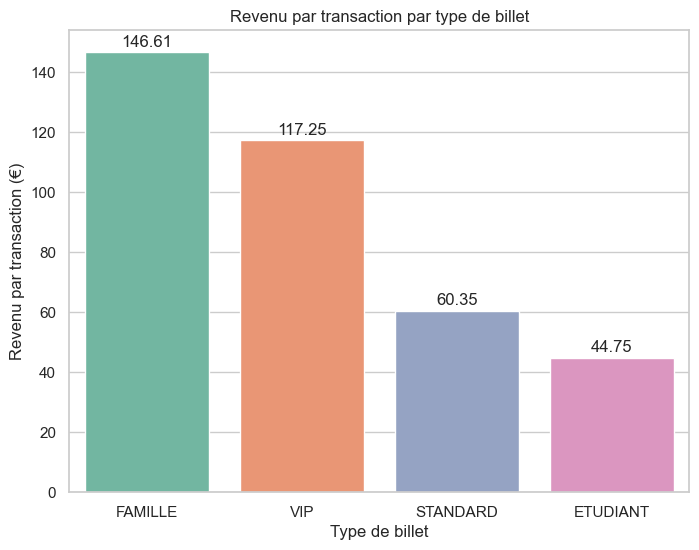

In [3]:
# Visualisation revenu/transaction par type de billet
kpi_rev_par_trans_type_billet = kpi_rev_par_trans_type_billet.sort_values("revenu_par_transaction", ascending = False).reset_index()
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data = kpi_rev_par_trans_type_billet,
    x = "Type_Billet",
    y = "revenu_par_transaction",
    hue = "Type_Billet",
    palette = "Set2",
    legend = False
)

plt.title("Revenu par transaction par type de billet")
plt.xlabel("Type de billet")
plt.ylabel("Revenu par transaction (€)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)

plt.show()

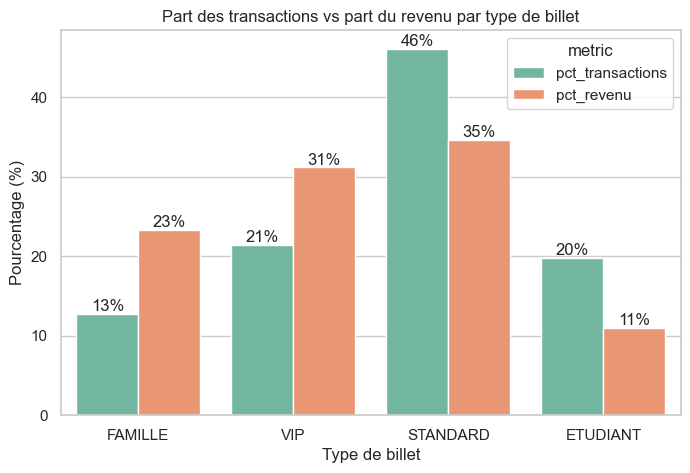

In [4]:
# Part des types de billet dans le total des transactions et des dépenses
kpi_rev_par_trans_type_billet["pct_transactions"] = kpi_rev_par_trans_type_billet["transaction"] / kpi_rev_par_trans_type_billet["transaction"].sum() * 100
kpi_rev_par_trans_type_billet["pct_revenu"] = kpi_rev_par_trans_type_billet["revenu"] / kpi_rev_par_trans_type_billet["revenu"].sum() * 100

# Visualisation
kpi_plot = kpi_rev_par_trans_type_billet.reset_index()

kpi_melt = kpi_plot.melt(
    id_vars="Type_Billet",
    value_vars=["pct_transactions", "pct_revenu"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=kpi_melt,
    x="Type_Billet",
    y="value",
    hue="metric",
    palette="Set2"
)

plt.title("Part des transactions vs part du revenu par type de billet")
plt.xlabel("Type de billet")
plt.ylabel("Pourcentage (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", padding=0)

plt.show()

Observations : 
---
- De nouveau, ces graphiques doivent être interprétés avec précaution puisqu'ils ne se basent pas sur l'affluence réelle mais le nombre d'actes d'achat.
- Les billets FAMILLE représentent seulement 12,8% des achats par les clients mais 23,3% des dépenses de ceux-ci.
- Les billets VIP se vendent mieux avec 21,4% des achats et sont associées à des dépenses par transaction élevées.

---
# 3. Impact de la campagne promotionnelle 
---

In [5]:
# Séparation en deux sous-ensembles 
df_avant = df[df["Période"] == "Avant"]  # Seulement les entrées avant la campagne
df_apres = df[df["Période"] == "Après"]  # Seulement les entrées après la campagne

In [6]:
# Comparaison moyenne, médiane, écart type avant et après la campagne

def stats_desc(dataframe) : 
    moy = np.mean(dataframe["Revenu_Total"]) 
    mediane = np.median(dataframe["Revenu_Total"])   
    ecart_type = np.std(dataframe["Revenu_Total"])   
    return pd.DataFrame(data = {"Moyenne" : [moy], "Médiane" : [mediane], "Ecart Type" : [ecart_type]}, index = [dataframe["Période"].astype(str).unique()])

pd.concat([stats_desc(df_avant), stats_desc(df_apres)]) 

,Moyenne,Médiane,Ecart Type
Avant,78.422931,60.43,41.186722
Après,81.733081,64.13,44.098984


Observations :
---
- Moyenne : La dépense totale moyenne est plus élevée après la campagne
- Médiane : Écart sensiblement équivalent à celui existant entre les moyennes, toujours à l'avantage de la période après
- Ecart type : quasi identique

Ces résultats laissent penser que la campagne a eu un effet positif sur la dépense moyenne et médiane des visiteurs.

<Axes: xlabel='Revenu_Total', ylabel='Density'>

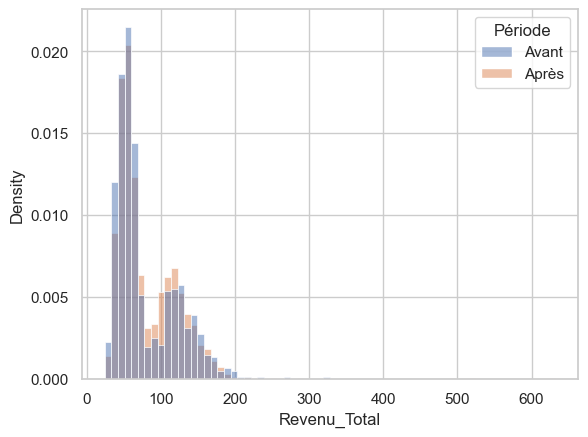

In [7]:
sns.histplot(
    data=df,
    x="Revenu_Total",
    hue="Période",
    stat="density",
    common_norm=False
)

Observations : 
---
- La distribution des dépenses montre deux catégories de dépenses. Une grosse partie entre 30 et 70 € et une deuxième partie, moins concentrée, entre 90 et 140 €.
- La première catégorie semble plus présente avant la campagne. La seconde semble plus présente après. 

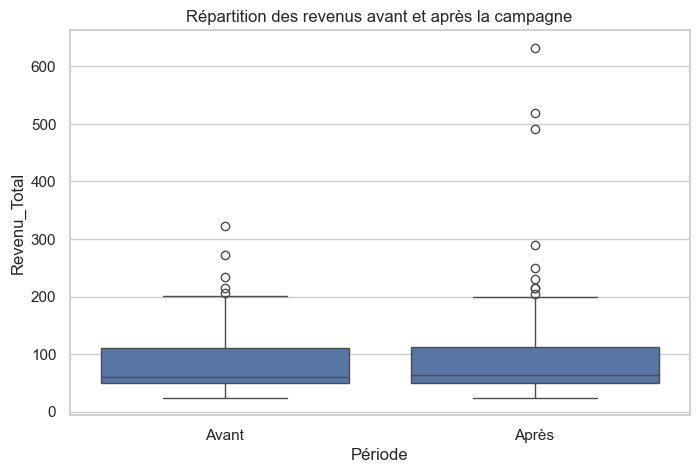

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Période",
    y="Revenu_Total"
)

plt.title("Répartition des revenus avant et après la campagne")
plt.show()

Observations : 
--- 
- Les distributions de revenu journalier avant et après la campagne sont très proches
- La médiane semble cependant plus élevée après qu'avant la campagne.
- Un test t de Welch doit être réalisé pour confirmer ou infirmer statistiquement cette analyse visuelle.

### Tests statistiques

In [9]:
# Différence de moyenne 
diff = np.mean(df_apres["Revenu_Total"]) - np.mean(df_avant["Revenu_Total"])

# Test t de Welch 
t_stat, p_value_ttest = stats.ttest_ind(df_avant["Revenu_Total"], df_apres["Revenu_Total"], equal_var= False)

print(f"Différence entre achat moyen avant vs après la campagne : {diff:.2f}€\nStatistique du test t de Welch : {t_stat:.5f} \nP-value : {p_value_ttest:.5f}")

Différence entre achat moyen avant vs après la campagne : 3.31€
Statistique du test t de Welch : -1.90613 
P-value : 0.05676


Interprétation : 
---
- La différence entre les moyennes des revenus totaux n'est pas statistiquement significative à un seuil de 5%.
- Mais la p-value est proche de ce seuil. Sa valeur peut être sensible aux décisions prises lors du nettoyage des données, notamment la conservation de la grande majorité des valeurs détectées comme extrèmes.
- Cela signifie qu'on peut pas affirmer avec confiance que la campagne a eu un effet sur la moyenne des dépenses des visiteurs. Pour autant, il n'est pas à exclure que cela ait été le cas

In [10]:
# Activité quotidienne
print(f"Activité quotidienne avant la campagne : {len(df_avant)/len(df_avant["Date_Visite"].unique()):.2f}")
print(f"Activité quotidienne après la campagne : {len(df_apres)/len(df_apres["Date_Visite"].unique()):.2f}")

# Test t de Welsh
t_stat, p_value_ttest = stats.ttest_ind(df_avant["Date_Visite"].value_counts(),df_apres["Date_Visite"].value_counts(), equal_var= False)

print(f"\nStatistique du test t de Welsh : {t_stat:.5f} \nP-value : {p_value_ttest:.5f}")

Activité quotidienne avant la campagne : 13.40
Activité quotidienne après la campagne : 14.08

Statistique du test t de Welsh : -1.29515 
P-value : 0.19719


Interprétation : 
--- 
- La différence entre le nombre moyen de transactions quotidiennes avant et après la campagne n'est pas statistiquement significative
- Les données disponibles ne permettent pas de conclure à un impact de la campagne sur cette variable

---
# 4. Conclusions 
---

## Impact de la campagne promotionnelle

L'analyse des données de la campagne promotionnelle de FUNPARK met en évidence plusieurs éléments clés : 
- La dépense moyenne par transaction est plus élevée après la campagne
- La distribution des dépenses semble faire apparaître une augmentation globale de celles-ci
- Mais, les tests statistiques n'indiquent pas une différence significative des revenus moyens avant et après la campagne, bien que ce résultat soit susceptible d'être revu en fonction d'informations complémentaires sur les données
- De plus, les tests ne démontrent pas d'impact sur l'activité quotidienne

--> Ceci suggère la nécessité de nouveaux retours sur les données afin d'en fournir une analyse plus poussée

## Analyse des segments clients

- Les billets FAMILLE représentent une part réduite des achats de billet mais une part des revenus totaux significative grâce à une dépense totale par transaction la plus élevée
- Les clients VIP génèrent une part importante des revenus du groupe malgré un volume de ventes en retrait.
- Les billets STANDARD sont la plus grosse part des recettes grâce à leur poids dans les ventes (près d'un achat de billet sur 2)

--> Les revenus sont tirés principalement par les visiteurs STANDARD (effet volume) et VIP (effet valeur)

## Limites de l'étude

- Les données représentent des transactions et non l'affluence des sites. Ceci crée une difficulté sérieuse dans les estimations en raison de l'absence du nombre de billets ou de produits de restauration achetés.
- La comparaison avant vs après la campagne souffre de l'absence d'éléments supplémentaires externes pouvant influencer le nombre de transaction ou leur montant comme la météo.

## Recommandations 

- Conserver le billet VIP et renforcer la communication sur ce sujet
- Améliorer la fréquentation des familles
- Approfondir la collecte et le traitement des données afin d'en garantir une meilleure analyse